# Diffusion from scratch — writing **ՊԱՆԻՐ** by hand

A complete walkthrough of a denoising diffusion model, with nothing imported that does the real
work: the forward process, the loss, the training loop and both samplers are written out here.

| | lecture | what gets built |
|---|---|---|
| **Part 1** | L27–L29 | the engine, on 8×8 digits — fast, no download |
| **Part 2** | L29–L30 | the same engine on Armenian letters, class-conditional, and the word |

**Why digits first.** A diffusion sampler is easy to get subtly wrong, and a wrong sampler
produces plausible-looking noise rather than an obvious error. On 8×8 digits a full experiment
takes seconds, so mistakes surface immediately instead of after a long run on the letters.

**Where it ends.** In Part 2 we generate `Պ`, `Ա`, `Ն`, `Ի`, `Ր` one at a time and paste them side
by side. The result does not look like a word written by a person, and the last section measures
*exactly why* — with numbers, not impressions. That failure is the point of the whole chapter.

Seed `509` throughout. Everything runs on CPU.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# 16 GB laptop with integrated graphics: cap the threads, and never run two of these at once.
# See the freeze-safety note in ml/ch10_diffusion/py_src/diffusion_lib.py
torch.set_num_threads(4)

SEED = 509
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

print("torch", torch.__version__, "| threads", torch.get_num_threads())

torch 2.9.0+cpu | threads 4


---
# Part 1 — the engine, on 8×8 digits

`sklearn.datasets.load_digits` gives 1797 images at 8×8. Small on purpose: a 28×28 run is *hours*
on a laptop while the teaching value is identical, which is the same call `py_src/digits_ddpm.py`
makes for the chapter's own figures.

Images are scaled to $[-1, 1]$, because the model predicts noise drawn from $\mathcal{N}(0, I)$
and it helps for the data to live on a comparable scale.

torch.Size([1797, 1, 8, 8]) -1.0 1.0


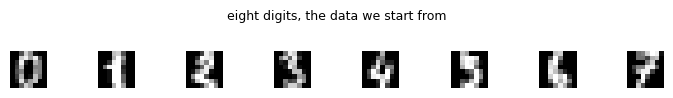

In [2]:
from sklearn.datasets import load_digits

d = load_digits()
X = d.images.astype(np.float32) / 16.0          # 0..1
X = torch.from_numpy(X * 2 - 1).unsqueeze(1)    # -> [-1, 1], shape (N, 1, 8, 8)
print(X.shape, X.min().item(), X.max().item())


def show(imgs, title, cols=8):
    """Tile images into a grid. Used throughout, so it lives here at the top."""
    imgs = np.asarray(imgs).squeeze()
    rows = int(np.ceil(len(imgs) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 0.9, rows * 0.95))
    for ax, img in zip(np.array(axes).ravel(), imgs):
        ax.imshow(img, cmap="gray", vmin=-1, vmax=1)
    for ax in np.array(axes).ravel():
        ax.axis("off")
    fig.suptitle(title, fontsize=9); plt.tight_layout(); plt.show()


show(X[:8], "eight digits, the data we start from")

## The noise schedule

The forward process needs $\beta_1 \dots \beta_T$, and from them $\alpha_t = 1-\beta_t$ and
$\bar\alpha_t = \prod_{s \le t}\alpha_s$.

$\sqrt{\bar\alpha_T}$ is the coefficient on the original image at the last step, and it is the
number to watch. If it is not tiny then $x_T$ is **not** a draw from $\mathcal{N}(0, I)$, and every
generated image inherits a bias from whatever noise it started from. This chapter hit exactly that
bug: at $T=400$, $\sqrt{\bar\alpha_T} = 0.132$ and the model was silently broken. Hence the
assertion — it is cheaper to crash here than to debug samples later.

sqrt(abar_T) = 0.0064   <- the signal really is gone by step T


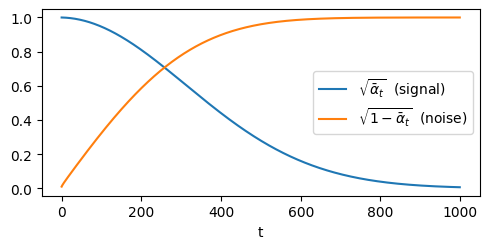

In [3]:
T = 1000

def linear_schedule(T, beta_start=1e-4, beta_end=0.02):
    return np.linspace(beta_start, beta_end, T)

def schedule_terms(betas):
    """betas -> (alphas, alpha_bars), where alpha_bar_t = prod_{s<=t} (1 - beta_s)."""
    alphas = 1.0 - betas
    return alphas, np.cumprod(alphas)

betas = linear_schedule(T)
alphas, abars = schedule_terms(betas)

assert abars[-1] ** 0.5 < 0.02, f"sqrt(abar_T)={abars[-1]**0.5:.4f} - forward process never reaches noise"
print(f"sqrt(abar_T) = {abars[-1] ** 0.5:.4f}   <- the signal really is gone by step T")

plt.figure(figsize=(5, 2.6))
plt.plot(np.sqrt(abars), label=r"$\sqrt{\bar\alpha_t}$  (signal)")
plt.plot(np.sqrt(1 - abars), label=r"$\sqrt{1-\bar\alpha_t}$  (noise)")
plt.xlabel("t"); plt.legend(); plt.tight_layout(); plt.show()

## The forward process, in one jump

The definition adds noise one step at a time, but L27 derives a closed form:

$$q(x_t \mid x_0) = \mathcal{N}\!\left(\sqrt{\bar\alpha_t}\,x_0,\;(1-\bar\alpha_t)I\right)
\qquad\Longleftrightarrow\qquad
x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon$$

**This is what makes training affordable.** Without it, every sample in every batch would need $t$
sequential steps. With it, jumping to step 700 costs exactly as much as jumping to step 1.

The check below runs the slow definition and the fast formula to the same noise level and compares
their statistics. The individual draws differ — they use different random noise — but the mean and
spread must agree, because they are the same distribution.

In [4]:
def q_sample(x0, t, eps, abars_t):
    """Closed form: jump straight to step t. t is a LongTensor of shape (B,)."""
    a = abars_t[t][:, None, None, None]
    return a.sqrt() * x0 + (1 - a).sqrt() * eps

abars_t = torch.tensor(abars, dtype=torch.float32)
betas_t = torch.tensor(betas, dtype=torch.float32)

x0, t_check = X[:1], 200

torch.manual_seed(SEED)
x_iter = x0.clone()
for s in range(t_check + 1):                     # the definition: one step at a time
    x_iter = (1 - betas_t[s]).sqrt() * x_iter + betas_t[s].sqrt() * torch.randn(x0.shape)

torch.manual_seed(SEED)
x_jump = q_sample(x0, torch.tensor([t_check]), torch.randn(x0.shape), abars_t)

print(f"iterative ({t_check} steps): mean {x_iter.mean():+.3f}  std {x_iter.std():.3f}")
print(f"closed form (1 step):       mean {x_jump.mean():+.3f}  std {x_jump.std():.3f}")

iterative (200 steps): mean -0.491  std 0.704
closed form (1 step):       mean -0.453  std 0.758


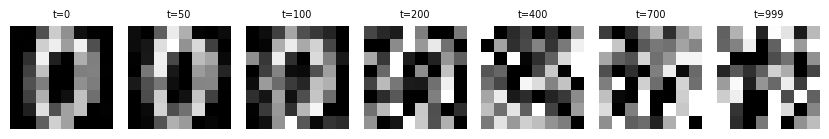

In [5]:
# The forward process, made visible: one digit dissolving as t grows
ts = [0, 50, 100, 200, 400, 700, 999]
fig, axes = plt.subplots(1, len(ts), figsize=(len(ts) * 1.2, 1.4))
for ax, t in zip(axes, ts):
    xt = q_sample(X[:1], torch.tensor([t]), torch.randn(X[:1].shape), abars_t)
    ax.imshow(xt[0, 0], cmap="gray", vmin=-1, vmax=1); ax.set_title(f"t={t}", fontsize=7); ax.axis("off")
plt.tight_layout(); plt.show()

## The model, and the loss that surprises everyone

L28 spends a full lecture going from maximum likelihood through the ELBO and a sum of KL
divergences, and lands here:

$$\mathcal{L} = \mathbb{E}_{t,x_0,\varepsilon}\left[\;\lVert \varepsilon - \varepsilon_\theta(x_t, t)\rVert^2\;\right]$$

**Mean squared error on the noise.** That is the whole objective. After a derivation that long, the
result being one line of `((pred - eps) ** 2).mean()` is the lecture's punchline.

One diagnostic worth internalising: the loss **starts near 1.0**. An untrained network predicts
roughly zero, so the error equals the variance of the noise it failed to predict, which is 1 by
construction. If a diffusion model's loss starts anywhere else, something upstream is wrong.

### First, how the network is told *how noisy* its input is

The denoiser sees $x_t$ but must behave very differently at $t=10$ and $t=900$. Passing the raw
integer works badly, so $t$ is expanded into a bank of sines and cosines at different
frequencies — the same construction as transformer positional encoding — and added to the
network's channels as a bias.

embedding shape: (4, 32)


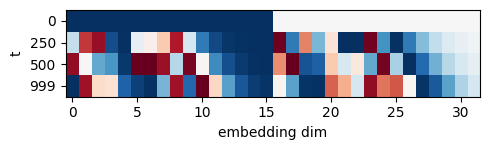

In [6]:
def timestep_embedding(t, dim=32):
    """Sinusoidal embedding, so the network knows *how noisy* its input is."""
    half = dim // 2
    freqs = torch.exp(-np.log(10000) * torch.arange(half, dtype=torch.float32) / half)
    a = t[:, None].float() * freqs[None]
    return torch.cat([torch.cos(a), torch.sin(a)], dim=-1)


emb = timestep_embedding(torch.tensor([0, 250, 500, 999]))
print("embedding shape:", tuple(emb.shape))
plt.figure(figsize=(5, 1.6))
plt.imshow(emb, aspect="auto", cmap="RdBu"); plt.yticks(range(4), [0, 250, 500, 999])
plt.ylabel("t"); plt.xlabel("embedding dim"); plt.tight_layout(); plt.show()

Each row is a different timestep, and they look clearly different — which is all the network
needs.

### The network

Given to you, because the architecture is not what this chapter teaches. It is a small UNet:
downsample once, process, upsample back, with a skip connection carrying the fine detail across.

In [7]:
class EpsNet(nn.Module):
    """Small UNet-ish denoiser for 8x8. Time enters as a per-channel bias."""

    def __init__(self, ch=48, t_dim=32):
        super().__init__()
        self.t_dim = t_dim
        self.t_proj = nn.Sequential(nn.Linear(t_dim, ch), nn.SiLU(), nn.Linear(ch, ch))
        self.down = nn.Sequential(nn.Conv2d(1, ch, 3, padding=1), nn.SiLU(),
                                  nn.Conv2d(ch, ch, 3, padding=1), nn.SiLU())
        self.mid = nn.Sequential(nn.Conv2d(ch, ch * 2, 3, stride=2, padding=1), nn.SiLU(),
                                 nn.Conv2d(ch * 2, ch * 2, 3, padding=1), nn.SiLU(),
                                 nn.ConvTranspose2d(ch * 2, ch, 4, stride=2, padding=1), nn.SiLU())
        self.out = nn.Sequential(nn.Conv2d(ch * 2, ch, 3, padding=1), nn.SiLU(),
                                 nn.Conv2d(ch, 1, 3, padding=1))

    def forward(self, x, t):
        h = self.down(x) + self.t_proj(timestep_embedding(t, self.t_dim))[:, :, None, None]
        return self.out(torch.cat([h, self.mid(h)], dim=1))


print(f"EpsNet: {sum(p.numel() for p in EpsNet().parameters()):,} parameters")

EpsNet: 265,537 parameters


### And the objective itself

Four lines. Pick a random noise level, noise the batch to it, ask the network what noise was
added, and score with mean squared error.

In [8]:
def loss_fn(model, x0, abars_t, T, gen):
    """Noise a batch to a random t, then predict the noise back. That is the whole objective."""
    t = torch.randint(0, T, (len(x0),), generator=gen)
    eps = torch.randn(x0.shape, generator=gen)
    xt = q_sample(x0, t, eps, abars_t)
    return ((model(xt, t) - eps) ** 2).mean()


torch.manual_seed(SEED)
_probe = EpsNet()
print(f"untrained loss: {loss_fn(_probe, X[:128], abars_t, T, torch.Generator().manual_seed(SEED)):.3f}"
      "   <- near 1.0, as expected")

untrained loss: 1.022   <- near 1.0, as expected


## Training

A couple of minutes on CPU. The cosine learning-rate decay matters more than it looks: without it
this chapter's spiral model was visibly undertrained, and adding it moved the final loss from
0.298 to 0.158.

step   250  loss 0.1815


step   500  loss 0.1055


step   750  loss 0.0969


step  1000  loss 0.0910


step  1250  loss 0.0876


step  1500  loss 0.0847


step  1750  loss 0.0845


step  2000  loss 0.0817


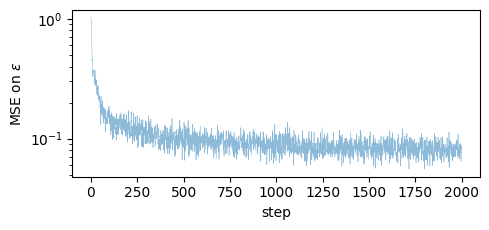

In [9]:
STEPS, BATCH = 2000, 128

torch.manual_seed(SEED)
model = EpsNet()
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=STEPS)
gen = torch.Generator().manual_seed(SEED)

losses = []
for step in range(1, STEPS + 1):
    i = torch.randint(0, len(X), (BATCH,), generator=gen)
    loss = loss_fn(model, X[i], abars_t, T, gen)
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    losses.append(loss.item())
    if step % 250 == 0:
        print(f"step {step:5d}  loss {np.mean(losses[-250:]):.4f}")

plt.figure(figsize=(5, 2.4))
plt.plot(losses, lw=0.4, alpha=0.5); plt.yscale("log")
plt.xlabel("step"); plt.ylabel(r"MSE on $\epsilon$"); plt.tight_layout(); plt.show()

## The reverse process

Now run it backwards. Start from pure noise and repeat, for $t = T-1 \dots 0$:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,
\varepsilon_\theta(x_t,t)\right) + \sqrt{\beta_t}\,z,
\qquad z \sim \mathcal{N}(0,I) \;\text{for}\; t>0$$

About fifteen lines. Note the `add_noise` flag — the next section needs it.

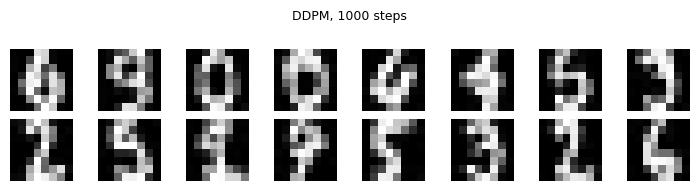

In [10]:
@torch.no_grad()
def sample_ddpm(model, n, betas_t, abars_t, add_noise=True, size=8, seed=SEED):
    torch.manual_seed(seed)
    alphas_t = 1 - betas_t
    x = torch.randn(n, 1, size, size)
    for t in range(len(betas_t) - 1, -1, -1):
        t_b = torch.full((n,), t, dtype=torch.long)
        eps = model(x, t_b)
        mean = (x - betas_t[t] / (1 - abars_t[t]).sqrt() * eps) / alphas_t[t].sqrt()
        x = (mean + betas_t[t].sqrt() * torch.randn_like(x)) if (add_noise and t > 0) else mean
    return x.clamp(-1, 1)


show(sample_ddpm(model, 16, betas_t, abars_t), "DDPM, 1000 steps")

## Delete one line and watch it collapse

The most counter-intuitive line in L29 is the $\sqrt{\beta_t}\,z$ term — the sampler *adds noise
back* at every step, having just spent the whole step removing some. Run it again with
`add_noise=False` and the reason becomes visible.

**What to look for:** the two printed numbers below are the standard deviation *across* the 16
samples. If the noise term matters, removing it should make that number collapse.

spread across samples, with noise:    0.4407
spread across samples, without noise: 0.0389


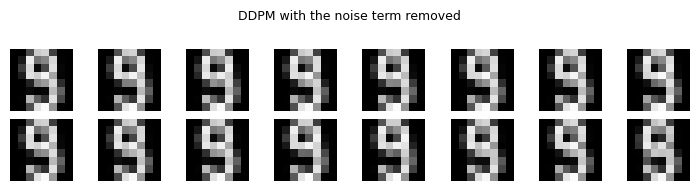

In [11]:
with_noise = sample_ddpm(model, 16, betas_t, abars_t, add_noise=True)
without    = sample_ddpm(model, 16, betas_t, abars_t, add_noise=False)

print(f"spread across samples, with noise:    {float(with_noise.std(dim=0).mean()):.4f}")
print(f"spread across samples, without noise: {float(without.std(dim=0).mean()):.4f}")

show(without, "DDPM with the noise term removed")

**What happened.** Every sample collapses toward the same image, and the spread across samples
drops sharply.

The reverse process is a **sampler**, not a denoiser. Each step computes the *mean* of
$p(x_{t-1} \mid x_t)$, and taking the mean every time turns the whole chain into repeated
mean-seeking: whatever noise you start from, you descend to the same high-density point, which is
roughly the average of the training data. The injected noise is what keeps the chain exploring the
distribution instead of walking to its centre.

A useful way to hold it: without the noise you are computing *the* most likely image; with it, you
are drawing *an* image.

## DDIM — the same model, 40× fewer steps

DDPM needs all $T$ steps because each one injects fresh randomness that must be undone gradually.
DDIM (Song et al., 2020) is **deterministic**: predict $\hat{x}_0$, then jump straight to any
earlier timestep.

$$\hat{x}_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\,\varepsilon_\theta}{\sqrt{\bar\alpha_t}},
\qquad
x_{t_{\text{prev}}} = \sqrt{\bar\alpha_{t_{\text{prev}}}}\,\hat{x}_0
+ \sqrt{1-\bar\alpha_{t_{\text{prev}}}}\,\varepsilon_\theta$$

**No retraining.** The same weights are reused — only the sampling loop changes.

DDPM-1000:   4.0 s
DDIM- 25:   0.1 s   (34.4x faster)


DDIM- 50:   0.2 s   (20.2x faster)


DDIM-100:   0.4 s   (10.1x faster)


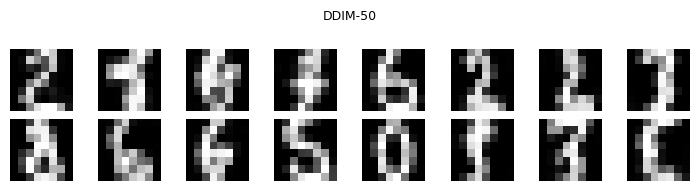

In [12]:
@torch.no_grad()
def sample_ddim(model, n, abars_t, n_steps=50, size=8, seed=SEED):
    torch.manual_seed(seed)
    ts = np.linspace(len(abars_t) - 1, 0, n_steps).round().astype(int)
    x = torch.randn(n, 1, size, size)
    for i, t in enumerate(ts):
        t_b = torch.full((n,), int(t), dtype=torch.long)
        eps = model(x, t_b)
        ab = abars_t[t]
        x0_hat = (x - (1 - ab).sqrt() * eps) / ab.sqrt()
        ab_prev = abars_t[ts[i + 1]] if i + 1 < len(ts) else torch.tensor(1.0)
        x = ab_prev.sqrt() * x0_hat + (1 - ab_prev).sqrt() * eps
    return x.clamp(-1, 1)


import time
t0 = time.perf_counter(); sample_ddpm(model, 16, betas_t, abars_t); ddpm_s = time.perf_counter() - t0
print(f"DDPM-{T}: {ddpm_s:5.1f} s")
for n_steps in (25, 50, 100):
    t0 = time.perf_counter(); sample_ddim(model, 16, abars_t, n_steps=n_steps)
    s = time.perf_counter() - t0
    print(f"DDIM-{n_steps:3d}: {s:5.1f} s   ({ddpm_s / s:4.1f}x faster)")

show(sample_ddim(model, 16, abars_t, n_steps=50), "DDIM-50")

---
# Part 2 — ՊԱՆԻՐ

The engine works. Now point it at handwritten Armenian.

`data/mashtots_panir_24.npz` holds **4,481 letters at 24×24** in five classes, taken from the
[Mashtots dataset](https://www.kaggle.com/competitions/mashtots-dataset-v2) (70,060 images across
78 classes) and preprocessed:

| label | 0 | 1 | 2 | 3 | 4 |
|---|---|---|---|---|---|
| letter | Պ | Ա | Ն | Ի | Ր |

so `y = [0, 1, 2, 3, 4]` spells **ՊԱՆԻՐ** — which is also this course's difficulty unit.

Two preprocessing decisions matter later:

1. **Cropped to the ink before resizing.** The glyph fills only ~34–40 px of the original 64×64
   frame, so resizing the raw frame applies a 4× reduction to 1–2 px strokes and dissolves them —
   measured ink fraction 0.133 naive against **0.258** cropped.
2. **Contrast normalised per image**, since thin antialiased strokes peak around 150–190/255.

Step 1 has a consequence we return to at the end: every glyph was scaled to fill its own box, so
the model has never seen letters that differ in size.

torch.Size([4481, 1, 24, 24]) | per class: [930, 854, 898, 886, 913] | Պ Ա Ն Ի Ր


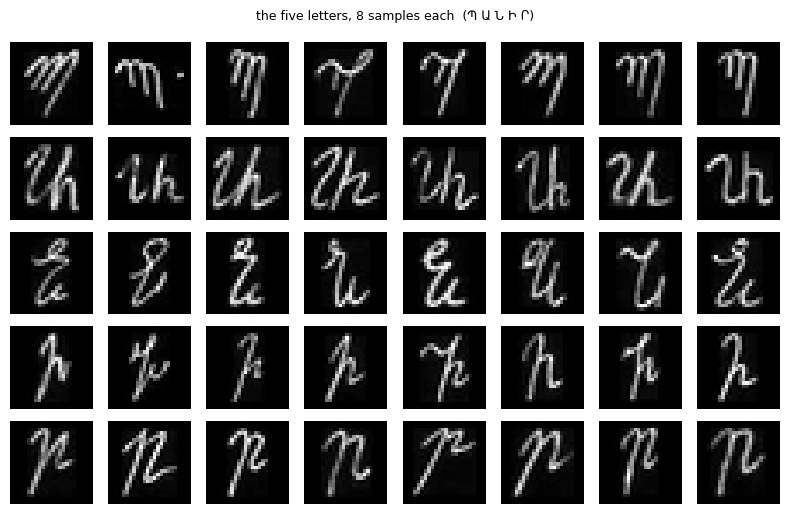

In [13]:
from pathlib import Path

data = np.load(Path("data") / "mashtots_panir_24.npz", allow_pickle=False)
XL = torch.from_numpy(data["X"].astype(np.float32) / 255.0 * 2 - 1).unsqueeze(1)
yL = torch.from_numpy(data["y"])
LETTERS = [str(s) for s in data["letters"]]

print(XL.shape, "| per class:", np.bincount(yL.numpy()).tolist(), "|", " ".join(LETTERS))

fig, axes = plt.subplots(5, 8, figsize=(8, 5.2))
for c in range(5):
    for ax, i in zip(axes[c], np.where(yL.numpy() == c)[0][:8]):
        ax.imshow(XL[i, 0], cmap="gray", vmin=-1, vmax=1); ax.axis("off")
plt.suptitle("the five letters, 8 samples each  (" + " ".join(LETTERS) + ")", fontsize=9)
plt.tight_layout(); plt.show()

## Look at the data before modelling it

Ink fraction — the share of pixels carrying ink — is the single most useful statistic here. It
predicts which class will be hardest, and it comes back at the end as the measure of what goes
wrong in the word.

In [14]:
for c, letter in enumerate(LETTERS):
    m = XL[yL == c]
    print(f"label {c}  {letter}   n={len(m):4d}   ink={float((m > 0).float().mean()):.3f}")

label 0  Պ   n= 930   ink=0.083
label 1  Ա   n= 854   ink=0.106
label 2  Ն   n= 898   ink=0.084
label 3  Ի   n= 886   ink=0.069
label 4  Ր   n= 913   ink=0.084


**Ի has the thinnest strokes by a clear margin** — 0.069 against 0.083–0.106 for the others. It
carries the least signal per image, so it is the class most likely to come out malformed. Keep that
prediction in mind; it is tested a few cells from now.

## A conditional model

To ask for a *particular* letter, the network needs the label as an input. Two changes to the
architecture:

- an `nn.Embedding(n_classes + 1, ch)` added alongside the time embedding;
- the extra index `n_classes` is a reserved **null token**, and during training the real label is
  replaced by it with probability ~0.15.

That null token is what makes classifier-free guidance possible: the *same* network provides both
the conditional prediction $\varepsilon_\theta(x,t,y)$ and the unconditional
$\varepsilon_\theta(x,t,\varnothing)$, with no second model.

**One design choice that turned out to matter more than anything else: the UNet halves the image
exactly once** (24 → 12 → 24). The obvious instinct is to go deeper, and that was tried — a
two-level version (24 → 12 → 6) with **7.03M** parameters trained for 20,000 steps produced
unreadable fragments, while this **1.50M** one-level model produced legible letters at a better
loss (0.0269 against 0.038).

The reason is the same fact that made cropping to the ink necessary: **these strokes are 1–2
pixels wide.** Halve twice and they are sub-pixel by the deep layers, so the extra capacity is
spent modelling a representation in which the letter has already been erased. More parameters
cannot recover information the architecture threw away.

The weights are loaded from `data/panir_ddpm_24.pt`, trained by `py_src/train_panir_ddpm.py`.

In [15]:
class CondEpsNet(nn.Module):
    """Conditional UNet with `levels` halvings. levels=1 is 24 -> 12 -> 24.

    Identical to CondUNet in py_src/train_panir_ddpm.py, so the shipped weights load here.
    """

    def __init__(self, n_classes, ch=96, levels=1, t_dim=32):
        super().__init__()
        self.t_dim, self.levels = t_dim, levels
        self.t_proj = nn.Sequential(nn.Linear(t_dim, ch), nn.SiLU(), nn.Linear(ch, ch))
        self.y_emb = nn.Embedding(n_classes + 1, ch)      # index n_classes == null token

        def block(i, o):
            return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.SiLU(),
                                 nn.Conv2d(o, o, 3, padding=1), nn.SiLU())

        chans = [ch * 2 ** i for i in range(levels + 1)]
        self.enc, self.downs, self.to_enc = nn.ModuleList(), nn.ModuleList(), nn.ModuleList()
        prev = 1
        for i in range(levels):
            self.enc.append(block(prev, chans[i]))
            self.to_enc.append(nn.Linear(ch, chans[i]))
            self.downs.append(nn.Sequential(
                nn.Conv2d(chans[i], chans[i + 1], 3, stride=2, padding=1), nn.SiLU()))
            prev = chans[i + 1]
        self.mid = block(chans[levels], chans[levels])
        self.to_mid = nn.Linear(ch, chans[levels])
        self.ups, self.dec = nn.ModuleList(), nn.ModuleList()
        for i in reversed(range(levels)):
            self.ups.append(nn.ConvTranspose2d(chans[i + 1], chans[i], 4, stride=2, padding=1))
            self.dec.append(block(chans[i] * 2, chans[i]))
        self.out = nn.Conv2d(ch, 1, 3, padding=1)

    def forward(self, x, t, y):
        c = self.t_proj(timestep_embedding(t, self.t_dim)) + self.y_emb(y)
        h, skips = x, []
        for i in range(self.levels):
            h = self.enc[i](h) + self.to_enc[i](c)[:, :, None, None]
            skips.append(h)
            h = self.downs[i](h)
        h = self.mid(h) + self.to_mid(c)[:, :, None, None]
        for j, i in enumerate(reversed(range(self.levels))):
            h = self.dec[j](torch.cat([self.ups[j](h), skips[i]], dim=1))
        return self.out(h)

Now load the trained weights. The shape check below is deliberate: a checkpoint from an
earlier run would otherwise load with mismatched keys and surface much later as garbled samples,
which reads like a modelling bug rather than a stale file.

In [16]:
WEIGHTS = Path("data") / "panir_ddpm_24.pt"
ckpt = torch.load(WEIGHTS, map_location="cpu", weights_only=False)
missing = {"ch", "levels", "n_classes", "size", "letters", "state_dict"} - set(ckpt)
if missing:
    raise RuntimeError(f"{WEIGHTS} is missing {sorted(missing)} - it predates the current model. "
                       "Regenerate with py_src/train_panir_ddpm.py")

cond = CondEpsNet(ckpt["n_classes"], ch=ckpt["ch"], levels=ckpt["levels"])
cond.load_state_dict(ckpt["state_dict"]); cond.eval()
print(f"loaded {sum(p.numel() for p in cond.parameters()):,} params, levels={ckpt['levels']}, "
      f"{ckpt['size']}x{ckpt['size']}, letters {' '.join(ckpt['letters'])}")

loaded 1,499,905 params, levels=1, 24x24, letters Պ Ա Ն Ի Ր


## Conditional sampling, with guidance

The sampler is the same as Part 1 with two additions: the label goes into every model call, and
classifier-free guidance extrapolates away from the unconditional prediction,

$$\tilde\varepsilon = \varepsilon_\theta(x,t,\varnothing)
+ w\,\bigl(\varepsilon_\theta(x,t,y) - \varepsilon_\theta(x,t,\varnothing)\bigr)$$

At $w=1$ this reduces to the conditional prediction and costs one forward pass; above 1 it costs
two, which is why guided sampling is roughly twice as slow.

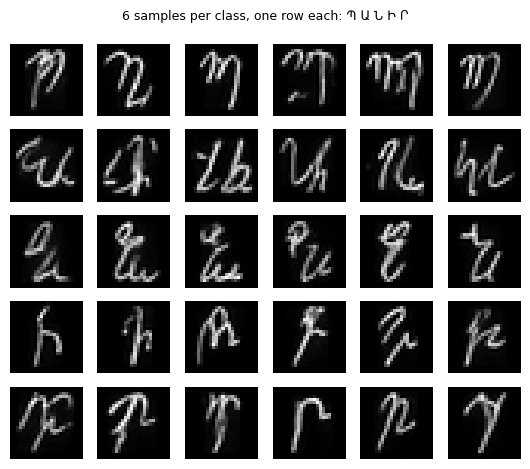

In [17]:
@torch.no_grad()
def sample_cond(model, y, betas_t, abars_t, guidance=1.0, mode="ddim", n_steps=50,
                size=24, seed=SEED):
    torch.manual_seed(seed)
    alphas_t = 1 - betas_t
    null = torch.full_like(y, model.y_emb.num_embeddings - 1)
    x = torch.randn(len(y), 1, size, size)

    def eps_at(x, t_b):
        e_c = model(x, t_b, y)
        if guidance == 1.0:
            return e_c
        e_u = model(x, t_b, null)                    # one call per branch, not two
        return e_u + guidance * (e_c - e_u)

    ts = (np.linspace(len(betas_t) - 1, 0, n_steps).round().astype(int) if mode == "ddim"
          else np.arange(len(betas_t) - 1, -1, -1))
    for i, t in enumerate(ts):
        t_b = torch.full((len(y),), int(t), dtype=torch.long)
        eps = eps_at(x, t_b)
        if mode == "ddim":
            ab = abars_t[t]
            x0h = (x - (1 - ab).sqrt() * eps) / ab.sqrt()
            ab_prev = abars_t[ts[i + 1]] if i + 1 < len(ts) else torch.tensor(1.0)
            x = ab_prev.sqrt() * x0h + (1 - ab_prev).sqrt() * eps
        else:
            mean = (x - betas_t[t] / (1 - abars_t[t]).sqrt() * eps) / alphas_t[t].sqrt()
            x = (mean + betas_t[t].sqrt() * torch.randn_like(x)) if t > 0 else mean
    return x.clamp(-1, 1)


show(sample_cond(cond, torch.arange(5).repeat_interleave(6), betas_t, abars_t),
     "6 samples per class, one row each: " + " ".join(LETTERS), cols=6)

## What training actually did

Before spelling anything, look at how the model got here. During training the *same word* was
sampled from the *same seed* every 1,000 steps, so the only thing that changes down this figure
is the model itself.

11 snapshots, 5 letters each, 24x24


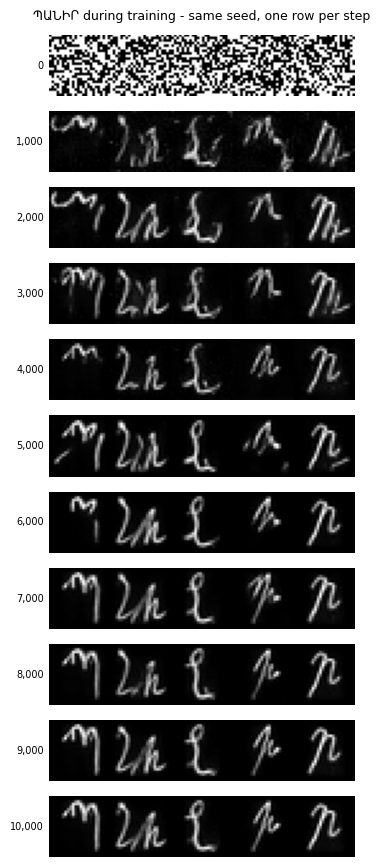

In [18]:
prog = np.load(Path("data") / "panir_progression_24.npz", allow_pickle=False)
steps, snaps = prog["steps"], prog["samples"]
print(f"{len(steps)} snapshots, {snaps.shape[1]} letters each, {snaps.shape[2]}x{snaps.shape[3]}")

fig, axes = plt.subplots(len(steps), 1, figsize=(5.5, 0.8 * len(steps)))
for ax, st, s in zip(axes, steps, snaps):
    ax.imshow(np.concatenate(list(s), axis=1), cmap="gray", vmin=-1, vmax=1)
    ax.set_ylabel(f"{st:,}", fontsize=7, rotation=0, ha="right", va="center")
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
fig.suptitle("ՊԱՆԻՐ during training - same seed, one row per step", fontsize=9)
plt.tight_layout(); plt.show()

Two things are worth reading off that ladder.

**Letters appear early.** By step 1,000 there are recognisable shapes; by 6,000 they have settled.
Almost nothing changes between 6,000 and 10,000 — and a separate 20,000-step run confirmed it,
looking identical from 4,000 onward. **Training longer was never the missing ingredient.**

**The wobble before it settles is the model finding the mode**, not becoming more accurate. Watch
`Ի` flicker between forms in the middle rows and then lock in. A loss curve cannot show you this;
it falls smoothly the whole way and says nothing about when the letters became letters.

## Spelling the word

One sample of each class, in order, pasted side by side.

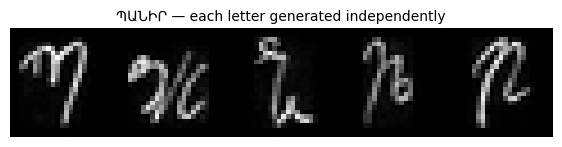

In [19]:
word = sample_cond(cond, torch.arange(5), betas_t, abars_t, mode="ddpm")
strip = np.concatenate([w[0].numpy() for w in word], axis=1)

plt.figure(figsize=(7, 1.8))
plt.imshow(strip, cmap="gray", vmin=-1, vmax=1); plt.axis("off")
plt.title("ՊԱՆԻՐ — each letter generated independently", fontsize=10)
plt.show()

## Why it does not look written by a person

This is what the chapter has been building toward. Rather than describing the result, measure it:
ink fraction as a proxy for stroke weight, the bounding box, and the vertical centre of mass.

In [20]:
def stats(img):
    a = img.squeeze().numpy() if torch.is_tensor(img) else np.asarray(img).squeeze()
    ys, xs = np.where(a > 0)
    if len(ys) == 0:
        return dict(ink=0.0, h=0, w=0, com_y=np.nan)
    return dict(ink=float((a > 0).mean()), h=int(ys.max() - ys.min() + 1),
                w=int(xs.max() - xs.min() + 1), com_y=float(ys.mean()))

print("generated:")
gen = [stats(w) for w in word]
for letter, s in zip(LETTERS, gen):
    print(f"  {letter}  ink={s['ink']:.3f}  h={s['h']:2d}  w={s['w']:2d}  com_y={s['com_y']:.1f}")

print("\nreal, one sample per class:")
real = [stats(XL[yL == c][0]) for c in range(5)]
for letter, s in zip(LETTERS, real):
    print(f"  {letter}  ink={s['ink']:.3f}  h={s['h']:2d}  w={s['w']:2d}  com_y={s['com_y']:.1f}")

for name, group in (("generated", gen), ("real", real)):
    ink = [s["ink"] for s in group]; com = [s["com_y"] for s in group]
    print(f"\n{name:9s} ink spread {max(ink) - min(ink):.3f}   com_y spread {max(com) - min(com):.1f}")

generated:
  Պ  ink=0.080  h=18  w=14  com_y=8.3
  Ա  ink=0.083  h=14  w=17  com_y=12.5
  Ն  ink=0.054  h=19  w=11  com_y=13.1
  Ի  ink=0.045  h=13  w=10  com_y=9.7
  Ր  ink=0.076  h=20  w=11  com_y=9.9

real, one sample per class:
  Պ  ink=0.090  h=19  w=16  com_y=7.6
  Ա  ink=0.113  h=18  w=15  com_y=11.6
  Ն  ink=0.062  h=19  w= 9  com_y=11.8
  Ի  ink=0.068  h=20  w= 8  com_y=10.9
  Ր  ink=0.066  h=19  w=11  com_y=9.1

generated ink spread 0.038   com_y spread 4.8

real      ink spread 0.050   com_y spread 4.1


**The model's assumption, written out.** Each letter was drawn from an independent sample of
noise, with no term coupling it to its neighbours:

$$p(\text{word}) = \prod_{i=1}^{5} p(\text{letter}_i \mid y_i)$$

A real handwritten word is not like that. It comes from **one hand, in one motion**, which
constrains every letter to share a stroke weight, a slant, and a baseline. The factorisation above
throws all of that away — there is simply no variable in the model through which letter 3 could
learn anything about letter 2.

**One caveat about the measurements.** Because every glyph was cropped and rescaled to fill its own
box during preprocessing, the bounding box `h`/`w` is *not* fair evidence about the model — the
size information was removed before training, so the model could not have reproduced it either way.
Ink fraction and centre of mass are the honest columns here.

> This is the same failure that makes image generators produce text-like marks that are not text.
> The model has learned what a letter looks like. Nothing has told it that letters standing next to
> each other belong to the same hand.

## What guidance actually costs

Sweeping $w$ with a fixed seed, so only the guidance changes.

The textbook story is that raising $w$ makes samples more canonical and less diverse. Worth
checking rather than assuming: when this chapter's spiral figures were built, the measurement
contradicted the slide and **the slide was rewritten**, because three well-separated classes were
already easy to condition on and high guidance simply pushed samples off the data manifold.

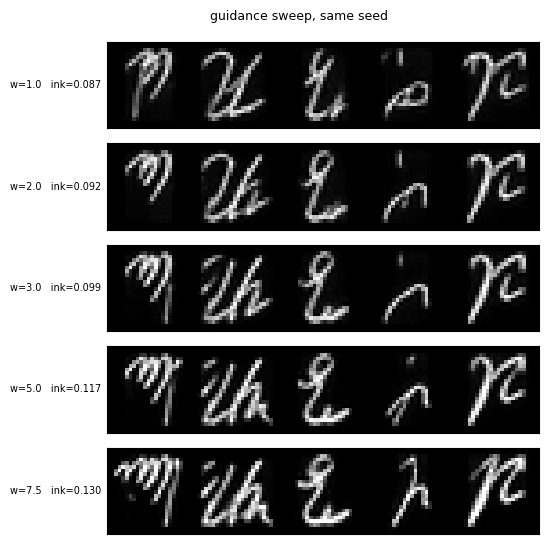

In [21]:
rows, labels = [], []
for w in (1.0, 2.0, 3.0, 5.0, 7.5):
    s = sample_cond(cond, torch.arange(5), betas_t, abars_t, guidance=w)
    rows.append(np.concatenate([im[0].numpy() for im in s], axis=1))
    labels.append(f"w={w}   ink={float((s > 0).float().mean()):.3f}")

fig, axes = plt.subplots(len(rows), 1, figsize=(6, 1.1 * len(rows)))
for ax, r, lab in zip(axes, rows, labels):
    ax.imshow(r, cmap="gray", vmin=-1, vmax=1)
    ax.set_ylabel(lab, fontsize=7, rotation=0, ha="right", va="center")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("guidance sweep, same seed", fontsize=9); plt.tight_layout(); plt.show()

---
## Where to take it next

- **Make the word look like one hand.** Nothing ties the five samples together. Try sharing part of
  the starting noise across them, or conditioning on a style vector, and check whether the ink and
  centre-of-mass spreads above actually shrink. This is genuinely open.
- **A different word.** `py_src/extract_mashtots.py` and `pack_mashtots.py` are parameterised by a
  single `LETTERS` list and the archive holds all 78 classes — ԻՐԱՆ, or your own name.
- **How few DDIM steps** before the letters stop being readable? Find the knee.
- **The size question.** Re-pack without per-glyph cropping, at 32×32 to keep the strokes alive, and
  see whether the model then reproduces the natural size variation it currently cannot.